In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=32"
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import orbax.checkpoint as ocp
import tensorstore as ts
jr.init_cluster()

#parameters
nx = 128
ny = 128
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 10.0
t_end = 10.0
cfl_safety = 0.5 
spatial_dimensions=3
snap_path="/Users/alfy/jax_scratch/ot3d"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,diss=(visc,res),hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
kgrid = jr.setup_kgrids(params)

rmhd-solver has initialized jax in 64bit precision.


Running in local mode. Total devices: 32


In [2]:
import jax_rmhd.snapshot_io as sn
snap=sn.load_snapshot(1,mngr,params)

ValueError: Topology mismatch detected. The checkpoint was saved with a different topology than the current one. Please provide a target tree with the desired topology to restore.

In [6]:
def get_precision_types():
    if jax.config.read("jax_enable_x64"):
        return jnp.float64, jnp.complex128
    else:
        return jnp.float32, jnp.complex64
    

def load_snapshot_v2(isnap,mngr,params):
    #This will load the whole snapshot into memory; on a cluster it should work in a distributed way.
    if params.spatial_dimensions==3:
        shape_complex = (params.nfields,params.nz, params.nx, params.ny // 2 + 1)
    else:
        shape_complex = (params.nx, params.ny // 2 + 1)
    ftype, ctype = get_precision_types()
    fields_like = jax.ShapeDtypeStruct(shape_complex, ctype,sharding=params.fields_sharding)
    state_like = jr.SimulationState(t=jax.ShapeDtypeStruct((), ftype), fields=fields_like)
    restore_args =  ocp.args.StandardRestore(fields_like)
    return mngr.restore(isnap, args=restore_args)

snap=load_snapshot_v2(1,mngr,params)

ValueError: User-provided restore item and on-disk value metadata tree structures do not match:
Mismatch:
    - Item: <class 'jax.ShapeDtypeStruct'>
    - Metadata: <class 'dict'>
If this mismatch is intentional, pass `partial_restore=True` to only restore parameters found in `item`.

In [8]:
params.state_sharding

SimulationState(t=None, fields=NamedSharding(mesh=Mesh('z_axis': 1, axis_types=(Auto,)), spec=P(None, 'z_axis', None, None), memory_kind=device))

In [ ]:
import orbax.checkpoint as ocp

# 1. Path directly to the item folder inside your checkpoint step directory
# structure: your_root_path / step_number / item_name
item_checkpoint_path = "/Users/alfy/jax_scratch/ot3d/1/default"

# 2. Use a raw StandardCheckpointer to extract the metadata directly from disk
checkpointer = ocp.StandardCheckpointer()
metadata = checkpointer.metadata(item_checkpoint_path)

# Handle API version differences (some versions wrap it in an object)
if hasattr(metadata, 'item_metadata'):
    tree_meta = metadata.item_metadata
else:
    tree_meta = metadata

# 3. Pull out the 'fields' leaf from your nested SimulationState structure
fields_meta = tree_meta['fields']

print("=== OVERALL METADATA ===")
print(f"Stored Array Shape: {fields_meta.shape}")
print(f"Stored Data Type:   {fields_meta.dtype}")

print("\n=== STORED SHARDING / TOPOLOGY ===")
print(fields_meta.sharding)

=== OVERALL METADATA ===
Stored Array Shape: (2, 128, 128, 65)
Stored Data Type:   complex64

=== STORED SHARDING / TOPOLOGY ===
NamedShardingMetadata(shape=[32], axis_names=['z_axis'], axis_types=(Auto,), partition_spec=(None, 'z_axis', None, None)) device_mesh=DeviceMetadataMesh(mesh=[DeviceMetadata(id=0), DeviceMetadata(id=2048), DeviceMetadata(id=4096), DeviceMetadata(id=6144), DeviceMetadata(id=8192), DeviceMetadata(id=10240), DeviceMetadata(id=12288), DeviceMetadata(id=14336), DeviceMetadata(id=16384), DeviceMetadata(id=18432), DeviceMetadata(id=20480), DeviceMetadata(id=22528), DeviceMetadata(id=24576), DeviceMetadata(id=26624), DeviceMetadata(id=28672), DeviceMetadata(id=30720), DeviceMetadata(id=32768), DeviceMetadata(id=34816), DeviceMetadata(id=36864), DeviceMetadata(id=38912), DeviceMetadata(id=40960), DeviceMetadata(id=43008), DeviceMetadata(id=45056), DeviceMetadata(id=47104), DeviceMetadata(id=49152), DeviceMetadata(id=51200), DeviceMetadata(id=53248), DeviceMetadata(id=

In [9]:
import orbax.checkpoint as ocp
import jax

def load_savio_snapshot_on_laptop(isnap, mngr, params):
    # Determine the array shape based on your parameters
    if params.spatial_dimensions == 3:
        shape_complex = (params.nfields, params.nz, params.nx, params.ny // 2 + 1)
    else:
        shape_complex = (params.nx, params.ny // 2 + 1)
        
    ftype, ctype = sn.get_precision_types()
    
    # 1. Define the local structure shape you want the data to enter (1 device footprint)
    fields_like = jax.ShapeDtypeStruct(shape_complex, ctype, sharding=params.fields_sharding)
    state_like = jr.SimulationState(t=jax.ShapeDtypeStruct((), ftype), fields=fields_like)
    
    # 2. Setup standard restore arguments targeting your local structure
    restore_args = ocp.args.StandardRestore(state_like)
    
    # 3. THE FIX: Define a clean transform mapping.
    # Passing ocp.Transform() for your items tells Orbax: 
    # "Ignore the mesh metadata saved inside the file on disk. Just strip away 
    # the 32-device constraints and cast the raw array data into our local target."
    transforms = {
        't': ocp.Transform(),
        'fields': ocp.Transform()
    }
    
    return mngr.restore(isnap, args=restore_args, transforms=transforms)

# Run this in your notebook cell to load your data safely!
snap = load_savio_snapshot_on_laptop(1, mngr, params)
print("Fields successfully loaded onto laptop! Shape:", snap.fields.shape)

TypeError: CheckpointManager.restore() got an unexpected keyword argument 'transforms'

In [11]:
import orbax.checkpoint as ocp
import jax

def load_savio_snapshot_on_laptop_direct(isnap, params):
    # 1. Recreate your abstract target shape layout
    if params.spatial_dimensions == 3:
        shape_complex = (params.nfields, params.nz, params.nx, params.ny // 2 + 1)
    else:
        shape_complex = (params.nx, params.ny // 2 + 1)
        
    ftype, ctype = sn.get_precision_types()
    
    fields_like = jax.ShapeDtypeStruct(shape_complex, ctype, sharding=params.fields_sharding)
    state_like = jr.SimulationState(t=jax.ShapeDtypeStruct((), ftype), fields=fields_like)
    
    # 2. Setup the empty transform mapping to strip Savio's hardware topology rules
    transforms = {
        't': ocp.Transform(),
        'fields': ocp.Transform()
    }
    
    # 3. Path directly to the 'default' item sub-folder inside your checkpoint directory
    item_checkpoint_path = f"/Users/alfy/jax_scratch/ot3d/{isnap}/default"
    
    # 4. Use your checkpointer passing the structure into 'item' instead of 'args'
    checkpointer = ocp.StandardCheckpointer()
    return checkpointer.restore(
        item_checkpoint_path, 
        item=state_like,       # Pass the structural template directly here
        transforms=transforms  # Pass the mesh-stripping transform directly here
    )

# Run this in your notebook cell:
snap = load_savio_snapshot_on_laptop_direct(1, params)
print("Fields successfully loaded onto laptop! Shape:", snap.fields.shape)

TypeError: StandardCheckpointer.restore() got an unexpected keyword argument 'item'

In [12]:
import tensorstore as ts
import jax.numpy as jnp

def load_fields_raw_bypass(isnap):
    # 1. Define the direct TensorStore specification pointing to the fields folder
    # Note: CheckpointManager saves the data under: step_number / item_name / leaf_name
    tspec = {
        'driver': 'zarr',
        'kvstore': {
            'driver': 'ocdbt',
            'base': f'file:///Users/alfy/jax_scratch/ot3d/{isnap}/default/',
            'path': 'fields'  
        }
    }

    # 2. Open the database block
    dataset = ts.open(ts.Spec(tspec), open=True).result()

    # 3. Read the global raw array directly from disk into memory
    raw_array = dataset.read().result()

    # 4. Cast it to a local JAX array on your laptop CPU
    return jnp.array(raw_array)

# Load snapshot 1
fields_data = load_fields_raw_bypass(1)

print("=== BYPASS SUCCESSFUL ===")
print("Fields array loaded cleanly onto laptop CPU!")
print("Shape:", fields_data.shape)
print("Dtype:", fields_data.dtype)

=== BYPASS SUCCESSFUL ===
Fields array loaded cleanly onto laptop CPU!
Shape: (2, 128, 128, 65)
Dtype: complex64


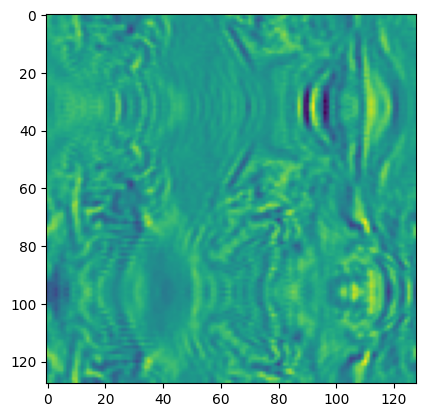

In [15]:
vort=ft.irfft2(-kgrid.ksq()*fields_data[0])
plt.imshow(vort[:,0,:])